# Evaluation and Empirical Results
## CI (Code-execution Invocation) vs DI (Direct Invocation) across Task Types

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import stats
import statsmodels.formula.api as smf
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': True,
    'axes.spines.bottom': True,
    'axes.linewidth': 0.8,
    'axes.grid': False,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'legend.frameon': False,
})

FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)

SHADE_DI = '#b3b3b3'
SHADE_CI = '#4d4d4d'
HATCH_DI = ''
HATCH_CI = '///'

In [2]:
df = pd.read_csv('final_merged_updated.csv')

TASK_MAP = {'T1': 'Single-tool', 'T2': 'Pipeline', 'T3': 'Discovery'}
AGENT_MAP = {
    'A1': 'Single-agent DI', 'A2': 'Single-agent CI',
    'A3': 'Multi-agent DI', 'A4': 'Multi-agent CI'
}
TASK_ORDER = ['T1', 'T2', 'T3']
TASK_LABELS = ['Single-tool', 'Pipeline', 'Discovery']

df['task_label'] = df['task_type'].map(TASK_MAP)
df['agent_name'] = df['agent_label'].map(AGENT_MAP)
df['mode'] = df['agent_label'].apply(lambda x: 'CI' if x in ['A2', 'A4'] else 'DI')
df['is_code'] = (df['mode'] == 'CI').astype(int)
df['is_multi'] = df['agent_label'].apply(lambda x: 1 if x in ['A3', 'A4'] else 0)

df['efficiency'] = df['task_grade'] / (df['total_tokens'] / 1000).replace(0, np.nan)

a1_eff = df[df['agent_label'] == 'A1'].groupby('task_type')['efficiency'].mean()
df['efficiency_norm'] = df.apply(
    lambda r: r['efficiency'] / a1_eff[r['task_type']], axis=1
)

print(f'Loaded {len(df)} runs | Modes: {df["mode"].value_counts().to_dict()}')
print(f'Task types: {df["task_type"].value_counts().sort_index().to_dict()}')

Loaded 582 runs | Modes: {'DI': 294, 'CI': 288}
Task types: {'T1': 204, 'T2': 216, 'T3': 162}


In [3]:
def ci_95(series):
    n = len(series.dropna())
    if n < 2:
        return 0
    return stats.t.ppf(0.975, n - 1) * series.std() / np.sqrt(n)

def run_ttest(g1, g2):
    t_stat, p_val = stats.ttest_ind(g1.dropna(), g2.dropna(), equal_var=False)
    cohen_d = (g1.mean() - g2.mean()) / np.sqrt((g1.std()**2 + g2.std()**2) / 2)
    return t_stat, p_val, cohen_d

def sig_stars(p):
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    return ''

def plot_mode_by_task(metric, ylabel, title, filename, ylim=None):
    fig, ax = plt.subplots(figsize=(7, 4))
    x = np.arange(len(TASK_ORDER))
    width = 0.35

    for i, (mode, shade, hatch, label) in enumerate([
        ('DI', SHADE_DI, HATCH_DI, 'Direct Invocation (DI)'),
        ('CI', SHADE_CI, HATCH_CI, 'Code-execution Invocation (CI)')
    ]):
        means, cis = [], []
        for tt in TASK_ORDER:
            subset = df[(df['task_type'] == tt) & (df['mode'] == mode)][metric]
            means.append(subset.mean())
            cis.append(ci_95(subset))
        ax.bar(x + i * width, means, width, yerr=cis, color=shade, hatch=hatch,
               edgecolor='black', linewidth=0.5, capsize=3, label=label,
               error_kw={'linewidth': 0.8})

    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(TASK_LABELS)
    ax.set_ylabel(ylabel)
    ax.legend(loc='best')
    if ylim:
        ax.set_ylim(ylim)
    fig.savefig(FIGURES_DIR / f'{filename}.pdf')
    fig.savefig(FIGURES_DIR / f'{filename}.png')
    plt.show()
    return fig

## 1. Task Grade by Invocation Mode

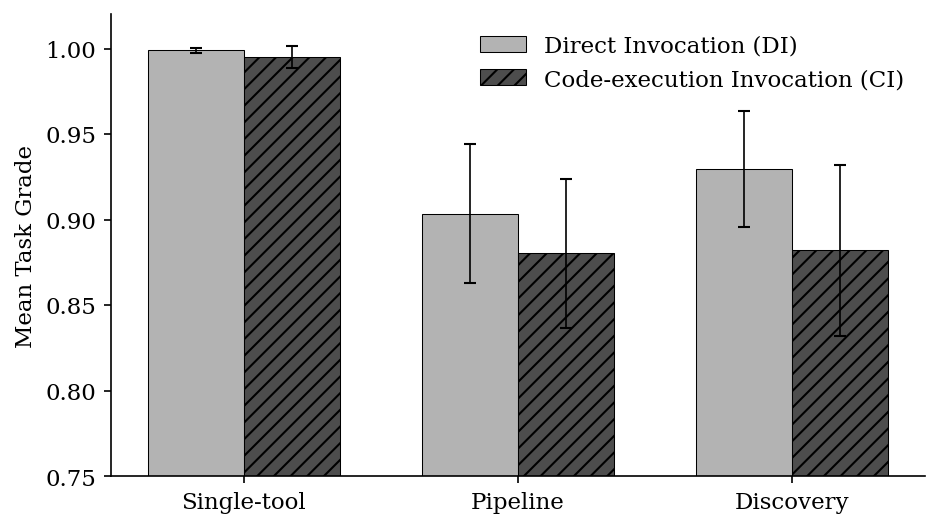


--- T-tests: Grade (CI vs DI) per task type ---
  Single-tool: DI=0.9990 CI=0.9951 | t=1.214, p=0.2272, d=0.170
  Pipeline: DI=0.9035 CI=0.8804 | t=0.770, p=0.4420, d=0.105
  Discovery: DI=0.9298 CI=0.8821 | t=1.576, p=0.1173, d=0.249

One-way ANOVA (grade ~ mode): F=2.456, p=0.1176


In [4]:
plot_mode_by_task('task_grade', 'Mean Task Grade', 'Task Grade by Invocation Mode',
                  'eval_grade_by_mode_task', ylim=(0.75, 1.02))

print('\n--- T-tests: Grade (CI vs DI) per task type ---')
for tt, tl in zip(TASK_ORDER, TASK_LABELS):
    ci = df[(df['task_type'] == tt) & (df['mode'] == 'CI')]['task_grade']
    di = df[(df['task_type'] == tt) & (df['mode'] == 'DI')]['task_grade']
    t, p, d = run_ttest(di, ci)
    print(f'  {tl}: DI={di.mean():.4f} CI={ci.mean():.4f} | '
          f't={t:.3f}, p={p:.4f}{sig_stars(p)}, d={d:.3f}')

groups = [g['task_grade'].values for _, g in df.groupby('mode')]
f_stat, p_val = stats.f_oneway(*groups)
print(f'\nOne-way ANOVA (grade ~ mode): F={f_stat:.3f}, p={p_val:.4f}{sig_stars(p_val)}')

## 2. Normalized Efficiency by Invocation Mode

In [ ]:
plot_mode_by_task('efficiency_norm', 'Normalised Efficiency',
                  'Normalised Efficiency by Invocation Mode',
                  'eval_efficiency_by_mode_task')

print('\n--- T-tests: Normalized Efficiency (CI vs DI) per task type ---')
for tt, tl in zip(TASK_ORDER, TASK_LABELS):
    ci = df[(df['task_type'] == tt) & (df['mode'] == 'CI')]['efficiency_norm']
    di = df[(df['task_type'] == tt) & (df['mode'] == 'DI')]['efficiency_norm']
    t, p, d = run_ttest(ci, di)
    print(f'  {tl}: DI={di.mean():.4f} CI={ci.mean():.4f} | '
          f't={t:.3f}, p={p:.4f}{sig_stars(p)}, d={d:.3f}')

groups = [g['efficiency_norm'].dropna().values for _, g in df.groupby('mode')]
f_stat, p_val = stats.f_oneway(*groups)
print(f'\nOne-way ANOVA (efficiency_norm ~ mode): F={f_stat:.3f}, p={p_val:.4f}{sig_stars(p_val)}')

## 3. Token Consumption by Invocation Mode

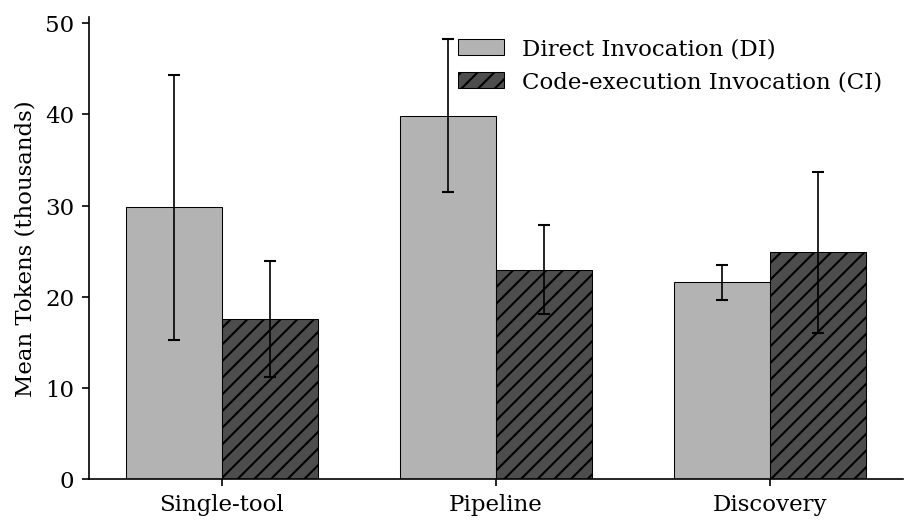


--- T-tests: Tokens (CI vs DI) per task type ---
  Single-tool: DI=29,825 CI=17,541 | t=1.538, p=0.1263, d=0.215
  Pipeline: DI=39,873 CI=22,999 | t=3.453, p=0.0007***, d=0.470
  Discovery: DI=21,584 CI=24,883 | t=-0.728, p=0.4684, d=-0.116

One-way ANOVA (tokens ~ mode): F=7.205, p=0.0075**


In [6]:
df['tokens_k'] = df['total_tokens'] / 1000
plot_mode_by_task('tokens_k', 'Mean Tokens (thousands)',
                  'Token Consumption by Invocation Mode',
                  'eval_tokens_by_mode_task')

print('\n--- T-tests: Tokens (CI vs DI) per task type ---')
for tt, tl in zip(TASK_ORDER, TASK_LABELS):
    ci = df[(df['task_type'] == tt) & (df['mode'] == 'CI')]['total_tokens']
    di = df[(df['task_type'] == tt) & (df['mode'] == 'DI')]['total_tokens']
    t, p, d = run_ttest(di, ci)
    print(f'  {tl}: DI={di.mean():,.0f} CI={ci.mean():,.0f} | '
          f't={t:.3f}, p={p:.4f}{sig_stars(p)}, d={d:.3f}')

groups = [g['total_tokens'].values for _, g in df.groupby('mode')]
f_stat, p_val = stats.f_oneway(*groups)
print(f'\nOne-way ANOVA (tokens ~ mode): F={f_stat:.3f}, p={p_val:.4f}{sig_stars(p_val)}')

## 4. Regression Analysis (Economics-Style Table)

In [7]:
formulas = {
    'M1': 'efficiency_norm ~ is_code',
    'M2': 'efficiency_norm ~ is_code + is_multi',
    'M3': 'efficiency_norm ~ is_code * is_multi',
    'M4': 'efficiency_norm ~ is_code * is_multi + C(task_type)',
    'M5': 'efficiency_norm ~ is_code * is_multi + C(task_type) + C(task_type):is_code + C(server)',
}

fits = {k: smf.ols(f, data=df).fit() for k, f in formulas.items()}

# Collect all coefficient names in order
coef_display = [
    ('Intercept', 'Intercept'),
    ('is_code', 'Code execution (CI)'),
    ('is_multi', 'Multi-agent'),
    ('is_code:is_multi', 'CI $\\times$ Multi-agent'),
    ('C(task_type)[T.T2]', 'Pipeline (T2)'),
    ('C(task_type)[T.T3]', 'Discovery (T3)'),
    ('C(task_type)[T.T2]:is_code', 'CI $\\times$ Pipeline'),
    ('C(task_type)[T.T3]:is_code', 'CI $\\times$ Discovery'),
]

model_names = list(fits.keys())

# Print table
print(f'{"":40s}', '  '.join(f'{m:>10s}' for m in model_names))
print('-' * (40 + 12 * len(model_names)))
for key, label in coef_display:
    row_coef = []
    row_se = []
    for m in model_names:
        if key in fits[m].params.index:
            c = fits[m].params[key]
            se = fits[m].bse[key]
            p = fits[m].pvalues[key]
            row_coef.append(f'{c:>8.4f}{sig_stars(p)}')
            row_se.append(f'({se:.4f})')
        else:
            row_coef.append(f'{"":>10s}')
            row_se.append(f'{"":>10s}')
    print(f'{label:40s}', '  '.join(f'{v:>10s}' for v in row_coef))
    print(f'{"":40s}', '  '.join(f'{v:>10s}' for v in row_se))

print('-' * (40 + 12 * len(model_names)))
print(f'{"Task type FE":40s}', '  '.join(
    f'{"Yes":>10s}' if 'C(task_type)' in formulas[m] else f'{"No":>10s}' for m in model_names))
print(f'{"Server FE":40s}', '  '.join(
    f'{"Yes":>10s}' if 'C(server)' in formulas[m] else f'{"No":>10s}' for m in model_names))
print(f'{"Observations":40s}', '  '.join(f'{fits[m].nobs:>10.0f}' for m in model_names))
print(f'{"R²":40s}', '  '.join(f'{fits[m].rsquared:>10.3f}' for m in model_names))
print(f'{"Adj. R²":40s}', '  '.join(f'{fits[m].rsquared_adj:>10.3f}' for m in model_names))

                                                 M1          M2          M3          M4          M5
----------------------------------------------------------------------------------------------------
Intercept                                  1.0762***    1.0742***    1.0000***    0.6823***    0.8886***
                                           (0.0467)    (0.0573)    (0.0659)    (0.0766)    (0.1080)
Code execution (CI)                          0.0978      0.0978    0.2478**    0.2512**   -0.3430**
                                           (0.0664)    (0.0664)    (0.0936)    (0.0897)    (0.1061)
Multi-agent                                              0.0041      0.1525      0.1525     0.1525*
                                                       (0.0664)    (0.0931)    (0.0892)    (0.0760)
CI $\times$ Multi-agent                                            -0.2999*    -0.2999*   -0.2954**
                                                                   (0.1324)    (0.1269)    (0.

In [8]:
# Generate LaTeX regression table
lines = []
lines.append(r'\begin{table}[H]')
lines.append(r'\caption{OLS regression: normalized efficiency (baseline = Single-agent DI).}\label{tab:regression}')
lines.append(r'\centering')
lines.append(r'\begin{tabular}{l' + 'c' * len(model_names) + '}')
lines.append(r'\toprule')
lines.append(' & '.join([''] + [f'({m})' for m in model_names]) + r' \\')
lines.append(r'\midrule')

for key, label in coef_display:
    vals = []
    ses = []
    for m in model_names:
        if key in fits[m].params.index:
            c = fits[m].params[key]
            se = fits[m].bse[key]
            p = fits[m].pvalues[key]
            vals.append(f'{c:.4f}{sig_stars(p)}')
            ses.append(f'({se:.4f})')
        else:
            vals.append('')
            ses.append('')
    lines.append(label + ' & ' + ' & '.join(vals) + r' \\')
    lines.append(' & ' + ' & '.join(ses) + r' \\')

lines.append(r'\midrule')
lines.append('Task type FE & ' + ' & '.join(
    'Yes' if 'C(task_type)' in formulas[m] else 'No' for m in model_names) + r' \\')
lines.append('Server FE & ' + ' & '.join(
    'Yes' if 'C(server)' in formulas[m] else 'No' for m in model_names) + r' \\')
lines.append(r'\midrule')
lines.append('Observations & ' + ' & '.join(f'{fits[m].nobs:.0f}' for m in model_names) + r' \\')
lines.append('$R^2$ & ' + ' & '.join(f'{fits[m].rsquared:.3f}' for m in model_names) + r' \\')
lines.append('Adj.\\ $R^2$ & ' + ' & '.join(f'{fits[m].rsquared_adj:.3f}' for m in model_names) + r' \\')
lines.append(r'\bottomrule')
lines.append(r'\end{tabular}')
lines.append(r'\end{table}')

latex_table = '\n'.join(lines)
print(latex_table)

\begin{table}[H]
\caption{OLS regression: normalized efficiency (baseline = Single-agent DI).}\label{tab:regression}
\centering
\begin{tabular}{lccccc}
\toprule
 & (M1) & (M2) & (M3) & (M4) & (M5) \\
\midrule
Intercept & 1.0762*** & 1.0742*** & 1.0000*** & 0.6823*** & 0.8886*** \\
 & (0.0467) & (0.0573) & (0.0659) & (0.0766) & (0.1080) \\
Code execution (CI) & 0.0978 & 0.0978 & 0.2478** & 0.2512** & -0.3430** \\
 & (0.0664) & (0.0664) & (0.0936) & (0.0897) & (0.1061) \\
Multi-agent &  & 0.0041 & 0.1525 & 0.1525 & 0.1525* \\
 &  & (0.0664) & (0.0931) & (0.0892) & (0.0760) \\
CI $\times$ Multi-agent &  &  & -0.2999* & -0.2999* & -0.2954** \\
 &  &  & (0.1324) & (0.1269) & (0.1081) \\
Pipeline (T2) &  &  &  & 0.4883*** & 0.1633 \\
 &  &  &  & (0.0747) & (0.1030) \\
Discovery (T3) &  &  &  & 0.4842*** & -0.1933 \\
 &  &  &  & (0.0805) & (0.1233) \\
CI $\times$ Pipeline &  &  &  &  & 0.8392*** \\
 &  &  &  &  & (0.1273) \\
CI $\times$ Discovery &  &  &  &  & 1.0190*** \\
 &  &  &  &  & (0.1

In [9]:
# Summary statistics for the .tex write-up
print('=== Summary Stats for LaTeX ===')
for metric, label in [('task_grade', 'Grade'), ('tokens_k', 'Tokens (K)'), ('efficiency_norm', 'Efficiency (norm)')]:
    print(f'\n--- {label} ---')
    summary = df.pivot_table(values=metric, index='task_type', columns='mode', aggfunc=['mean', ci_95])
    print(summary.round(4))

print('\n--- Overall mode means ---')
print(df.groupby('mode')[['task_grade', 'total_tokens', 'efficiency_norm']].mean().round(4))

print(f'\nDI tokens: {df[df["mode"]=="DI"]["total_tokens"].mean():,.0f}')
print(f'CI tokens: {df[df["mode"]=="CI"]["total_tokens"].mean():,.0f}')
print(f'Ratio: {df[df["mode"]=="DI"]["total_tokens"].mean() / df[df["mode"]=="CI"]["total_tokens"].mean():.2f}x')

=== Summary Stats for LaTeX ===

--- Grade ---
             mean           ci_95        
mode           CI      DI      CI      DI
task_type                                
T1         0.9951  0.9990  0.0063  0.0014
T2         0.8804  0.9035  0.0436  0.0406
T3         0.8821  0.9298  0.0498  0.0340

--- Tokens (K) ---
              mean            ci_95         
mode            CI       DI      CI       DI
task_type                                   
T1         17.5415  29.8248  6.3543  14.5123
T2         22.9992  39.8726  4.9224   8.3438
T3         24.8832  21.5843  8.8183   1.8882

--- Efficiency (norm) ---
             mean           ci_95        
mode           CI      DI      CI      DI
task_type                                
T1         0.5638  1.0545  0.0372  0.1983
T2         1.4717  1.1232  0.1458  0.1628
T3         1.5598  1.0422  0.1775  0.0999

--- Overall mode means ---
      task_grade  total_tokens  efficiency_norm
mode                                           
CI      